In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.optimize import linprog, linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle as pkl
import os
import math
warnings.simplefilter("ignore")

In [2]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)

In [3]:
DEBUG = True

In [54]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 12})

# readable legend keys
model_keys = [
    #"ideal",
    "content_5",
    #"content_10",
    #"pop",
    "mf",
    #"sf",
    #"random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

rs_colors = {
    'content_5' : 'mediumseagreen',
    #'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'tab:brown',
    'mf' : 'mediumorchid',
    'ideal' : 'tab:blue',
    'random' : 'tab:pink'
}

model_to_readable = {
    "ideal": "Ideal",
    "content_5": "Content-based Filtering",
    #"content_10": "Content Filtering 10 Tags",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

metric_names_to_readable = {
    "mean_util": "Mean Utility per Interaction",
    "inter": "Inter-user Diversity",
    "intra": "Intra-user Diversity",
    "homog": "General Homogenization",
    "sim_homog": "Similar Users Homogenization",
    "gini": "Gini Index",
    "cover": "Item Coverage",
    "choices": "Feed Choices of Users",
    "rs_util": "Mean Utility per RS choices",
    "rs_util_share": "Proportion of Utility comming from RS",
    "rs_influence": "RS Utility improvement"
}

In [5]:
folder_paths = ["/home/salveal/data/salveal/results19/rand_feed/r0"]
inpi=40

In [6]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()

In [7]:
user_prefs = np.array(final_results['user_prefs']['all'])
item_attrs = np.array(final_results['item_attrs']['all'])

In [8]:
interactions = dict()
for mo in model_keys + ["ideal"]:
    interactions[mo] = np.array(final_results['interaction_history'][mo])
    interactions[mo] = np.transpose(interactions[mo].reshape(interactions[mo].shape[:-1]), axes=[0,2,1])

In [9]:
utilities = dict()
for mo in model_keys:
    utilities[mo] = np.array(final_results['utility_history'][mo])
    utilities[mo] = np.transpose(utilities[mo], axes=[0,2,1])

In [10]:
traits = dict()
for mo in model_keys:
    traits[mo] = np.array(final_results['trait_history'][mo])
    traits[mo] = np.transpose(traits[mo], axes=[0,2,1,3])

In [11]:
ranks = dict()
for mo in model_keys:
    ranks[mo] = np.array(final_results['rank_history'][mo])
    ranks[mo] = np.transpose(ranks[mo], axes=[0,2,1])

In [12]:
util_ranks = dict()
for mo in model_keys:
    util_ranks[mo] = np.array(final_results['utility_rank_history'][mo])
    util_ranks[mo] = np.transpose(util_ranks[mo], axes=[0,2,1])

# Métricas

## Distribución de Utilidad

In [13]:
util_mean = dict()
for mo in model_keys:
    util_mean[mo] = []
    for i in range(utilities[mo].shape[0]):
        re = []
        for j in range(utilities[mo][i].shape[1]):
            util_mean_iter = utilities[mo][i][:,:(j+1)].mean()
            re.append(util_mean_iter)
        util_mean[mo].append(re)
    util_mean[mo] = np.array(util_mean[mo])

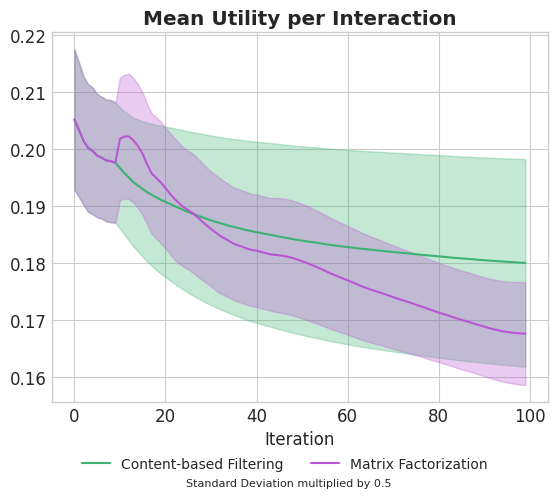

In [159]:
for mo in model_keys:
    values = gaussian_filter1d(util_mean[mo].mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])
    
    std = util_mean[mo].std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.title("Mean Utility per Interaction", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=2, fontsize=10)
plt.text(x=47, y=0.141, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

## Diversidad

### Inter-User Diversity

In [136]:
inter_user_div = dict()
for mo in model_keys:
    inter_user_div[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_mean = mean_user_attrs.mean(axis=0)
            distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
            variance = ((distances**2).sum())/distances.shape[0]
            re.append(variance**0.5)
        inter_user_div[mo].append(re)
    inter_user_div[mo] = np.array(inter_user_div[mo])

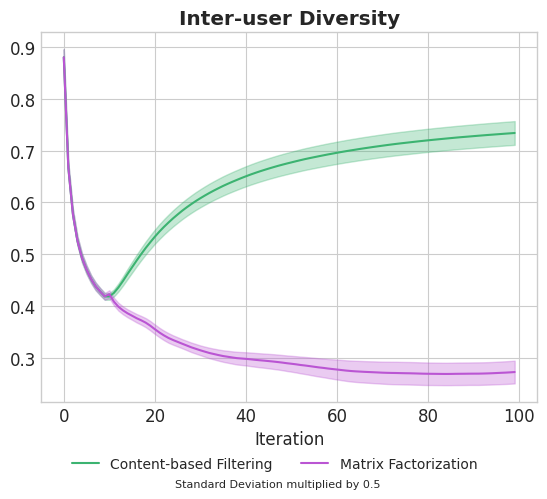

In [160]:
for mo in model_keys:
    values = gaussian_filter1d(inter_user_div[mo].mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])
    
    std = inter_user_div[mo].std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.title("Inter-user Diversity", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=2, fontsize=10)
plt.text(x=47, y=0.051, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

### Intra-User Diversity

In [145]:
intra_user_div = dict()
for mo in interactions.keys():
    intra_user_div[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
            distances = np.linalg.norm(diff_vectors, axis=2)
            variances = ((distances**2).sum(axis=1))/(distances.shape[1])
            re.append((variances**0.5).mean())
        intra_user_div[mo].append(re)
    intra_user_div[mo] = np.array(intra_user_div[mo])

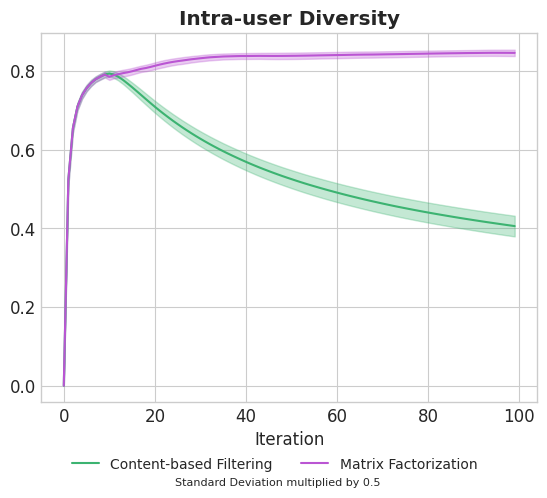

In [161]:
for mo in model_keys:
    values = gaussian_filter1d(intra_user_div[mo].mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])
    
    std = intra_user_div[mo].std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.title("Intra-user Diversity", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=2, fontsize=10)
plt.text(x=47, y=-0.255, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

### Filter Bubble Effect

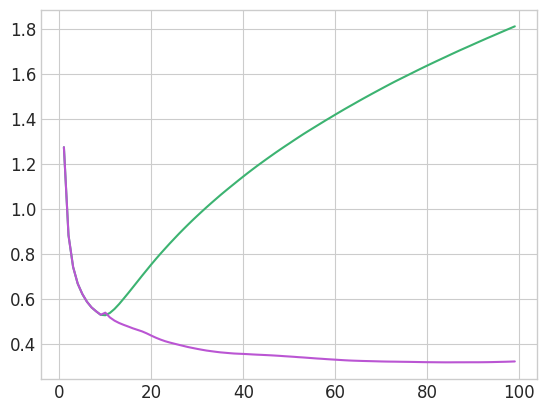

In [168]:
for mo in model_keys:
    fbe = (inter_user_div[mo].mean(axis=0)/intra_user_div[mo].mean(axis=0))
    values = gaussian_filter1d(fbe, sigma=0.1)
    plt.plot(values, color=rs_colors[mo])
plt.show()

### General Homogenization

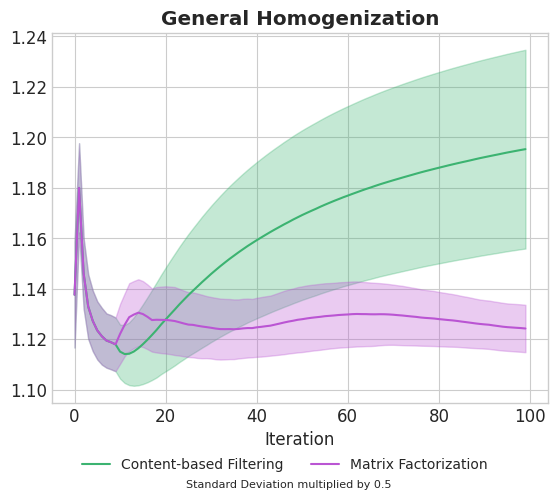

In [162]:
for mo in model_keys:
    homog = (inter_user_div[mo]**2 + intra_user_div[mo]**2)**(-0.5)
    values = gaussian_filter1d(homog.mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])

    std = homog.std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.title("General Homogenization", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=2, fontsize=10)
plt.text(x=47, y=1.061, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

### Gen Jaccard (basically igual que Anwar's Gen Homog)

In [ ]:
gen_Jacc = dict()
for mo in model_keys:
    gen_Jacc[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_indices = interactions[mo][i]
        for j in range(interactions[mo][i].shape[1]):
            m_u_a = user_iter_attrs[:,:(j+1)].mean(axis=1)
            user_jiter_indices = user_iter_indices[:,:(j+1)]
            nearest_users = get_sim_users_pairs(np.random.rand(m_u_a.shape[0], m_u_a.shape[0]))
            jacc = 0
            for p in nearest_users:
                setp0 = set(user_jiter_indices[p[0]])
                setp1 = set(user_jiter_indices[p[1]])
                jacc += len(setp0.intersection(setp1)) / len(setp0.union(setp1)) / len(nearest_users)
            re.append(jacc)
        gen_Jacc[mo].append(re)
    gen_Jacc[mo] = np.array(gen_Jacc[mo])

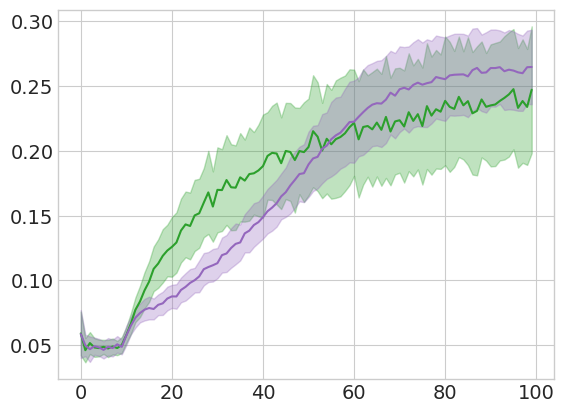

In [ ]:
for mo in model_keys:
    values = gaussian_filter1d(gen_Jacc[mo].mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo])

    std = gen_Jacc[mo].std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.show()

### Similar Users Homogenization (Chamfer distance)

In [22]:
from scipy.spatial.distance import cdist
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [30]:
chamfer = dict()
ideal_chamfer = dict()
for mo in model_keys:
    chamfer[mo] = []
    ideal_chamfer[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        re2 = []
        user_iter_attrs = item_attrs[i].T[interactions[mo][i]]
        user_iter_attrs_ideal = item_attrs[i].T[interactions['ideal'][i]]
        for j in range(user_iter_attrs.shape[1]):
            mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
            nearest_users = get_sim_users_pairs(mean_user_attrs)

            pairs_p_iter_attrs = user_iter_attrs[nearest_users]
            pair_inter_inter_d = np.zeros((pairs_p_iter_attrs.shape[0], j+1, j+1))
            ideal_pair_inter_inter_d = np.zeros((pairs_p_iter_attrs.shape[0], j+1, j+1))
            ideal_pairs_p_iter_attrs = user_iter_attrs_ideal[nearest_users]
            for p in range(pairs_p_iter_attrs.shape[0]):
                pair_inter_inter_d[p] = cdist(pairs_p_iter_attrs[p, 0, :(j+1)], pairs_p_iter_attrs[p, 1, :(j+1)], metric='euclidean')
                ideal_pair_inter_inter_d[p] = cdist(ideal_pairs_p_iter_attrs[p, 0, :(j+1)], ideal_pairs_p_iter_attrs[p, 1, :(j+1)], metric='euclidean')
            min_axis_0 = np.min(pair_inter_inter_d, axis=2)
            min_axis_1 = np.min(pair_inter_inter_d, axis=1)
            all_min_values = np.concatenate([min_axis_0.flatten(), min_axis_1.flatten()])
            chamfer_iter = np.mean(all_min_values)
            ideal_min_axis_0 = np.min(ideal_pair_inter_inter_d, axis=2)
            ideal_min_axis_1 = np.min(ideal_pair_inter_inter_d, axis=1)
            ideal_all_min_values = np.concatenate([ideal_min_axis_0.flatten(), ideal_min_axis_1.flatten()])
            ideal_chamfer_iter = np.mean(ideal_all_min_values)
            re.append(chamfer_iter)
            re2.append(ideal_chamfer_iter)
        chamfer[mo].append(re)
        ideal_chamfer[mo].append(re2)
    chamfer[mo] = np.array(chamfer[mo])
    ideal_chamfer[mo] = np.array(ideal_chamfer[mo])

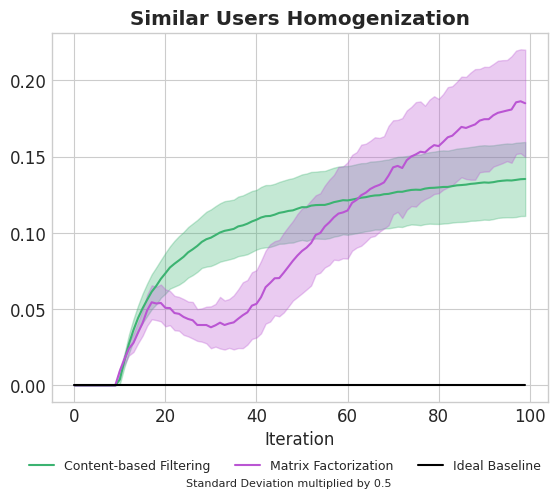

In [165]:
for mo in model_keys:
    sim_homog = ideal_chamfer[mo] - chamfer[mo]
    values = gaussian_filter1d(sim_homog.mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])

    std = sim_homog.std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.plot(np.zeros(values.shape[0], dtype=float), color="k", label="Ideal Baseline")
plt.title("Similar Users Homogenization", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=3, fontsize=9)
plt.text(x=47, y=-0.066, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

## Distribución de Items

### Gini

In [120]:
gini = dict()
for mo in model_keys:
    gini[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        for j in range(interactions[mo][i].shape[1]):
            num_items = (j+1)*inpi
            user_iter_interactions = interactions[mo][i][:,:(j+1)]
            item_interactions = np.bincount(user_iter_interactions.flatten(), minlength=num_items)
            item_ranks = np.argsort(np.argsort(-item_interactions)) + 1
            numerator = (((2*item_ranks) - num_items - 1) * item_interactions).sum()
            denominator = item_interactions.sum()
            gini_iter = - numerator / (num_items * denominator)
            re.append(gini_iter)
        gini[mo].append(re)
    gini[mo] = np.array(gini[mo])

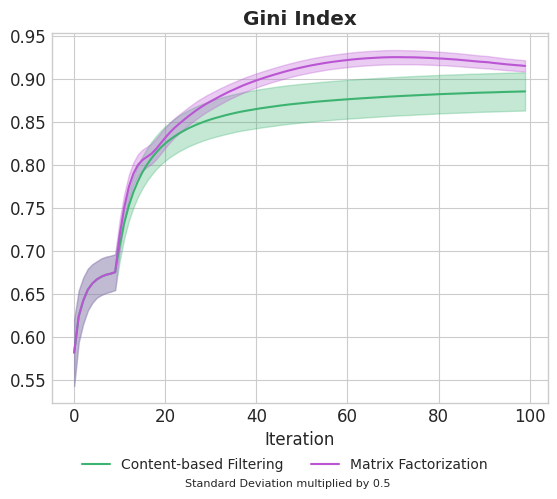

In [166]:
for mo in model_keys:
    values = gaussian_filter1d(gini[mo].mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])

    std = gini[mo].std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.title("Gini Index", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=2, fontsize=10)
plt.text(x=47, y=0.425, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

### Cobertura

In [131]:
cover = dict()
for mo in model_keys:
    cover[mo] = []
    for i in range(interactions[mo].shape[0]):
        re = []
        for j in range(interactions[mo][i].shape[1]):
            num_items = (j+1)*inpi
            user_iter_interactions = interactions[mo][i][:,:(j+1)]
            cover_iter = np.unique(user_iter_interactions).shape[0] / num_items
            re.append(cover_iter)
        cover[mo].append(re)
    cover[mo] = np.array(cover[mo])

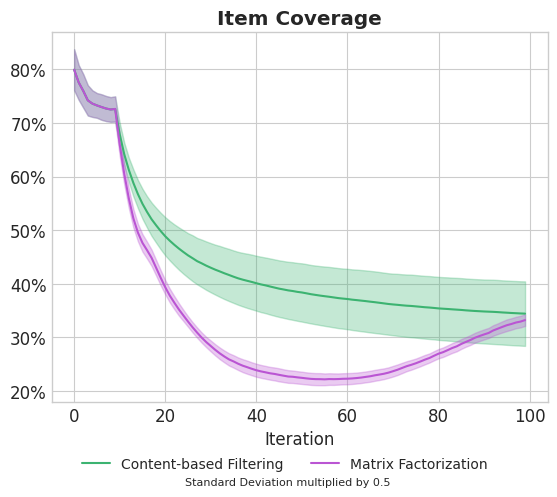

In [167]:
import matplotlib.ticker as ticker
for mo in model_keys:
    values = gaussian_filter1d(cover[mo].mean(axis=0), sigma=0.1)
    plt.plot(values, color=rs_colors[mo], label=model_to_readable[mo])

    std = cover[mo].std(axis=0)
    mtus = np.arange(len(std))
    low = values - 0.5 * std
    high = values + 0.5 * std
    low = gaussian_filter1d(low, sigma=0.1)
    high = gaussian_filter1d(high, sigma=0.1)
    plt.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)
plt.title("Item Coverage", fontweight="bold")
plt.xlabel("Iteration")
plt.legend(loc='lower center', bbox_to_anchor=(0.47, -0.22), ncol=2, fontsize=10)
plt.text(x=47, y=0.025, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
plt.show()